##Problem Statement -
Logistic regression to predict heart disease:
The dataset is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes.

Output variable: 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)


##Understanding the dataset


* The input (independent) variables are male, age, education, currentSmoker, cigsPerDay, BPMeds, prevalentStroke, prevalentHyp, diabetes, totChol, sysBP, diaBP, BMI, heartRate, and glucose. These 15 variables are used as input features to predict whether a patient is at risk of developing coronary heart disease within the next 10 years.
* The output (dependent/target) variable is TenYearCHD, which indicates whether a patient is likely to develop coronary heart disease within the next 10 years. It is a binary variable, where 1 represents "Yes" (at risk) and 0 represents "No" (not at risk).




In [1]:
#Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix, f1_score,classification_report

In [2]:
# Loading the heart disease dataset into a Pandas DataFrame.
df = pd.read_csv('/content/heart_disease.csv')

In [3]:
# Displaying the first five records to verify that the dataset has been loaded correctly.
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


##EDA Process begins

In [4]:
# Checking the number of rows and columns present in the dataset.
df.shape

(4238, 16)

The dataset contains 4238 patient records and 16 columns.

In [5]:
# Displaying dataset information, including data types, non-null counts, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [6]:
# Generating descriptive statistics for all numerical features.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4238.0,0.429212,0.495022,0.00,0.00,0.0,1.000,1.0
age,4238.0,49.584946,8.572160,32.00,42.00,49.0,56.000,70.0
education,4133.0,1.978950,1.019791,1.00,1.00,2.0,3.000,4.0
currentSmoker,4238.0,0.494101,0.500024,0.00,0.00,0.0,1.000,1.0
cigsPerDay,4209.0,9.003089,11.920094,0.00,0.00,0.0,20.000,70.0
BPMeds,4185.0,0.029630,0.169584,0.00,0.00,0.0,0.000,1.0
prevalentStroke,4238.0,0.005899,0.076587,0.00,0.00,0.0,0.000,1.0
prevalentHyp,4238.0,0.310524,0.462763,0.00,0.00,0.0,1.000,1.0
diabetes,4238.0,0.025720,0.158316,0.00,0.00,0.0,0.000,1.0
totChol,4188.0,236.721585,44.590334,107.00,206.00,234.0,263.000,696.0


In [7]:
# Identifying columns in which every value is unique.
unique_columns = [col for col in df.columns if df[col].nunique() == len(df)]
print(unique_columns)


[]


In [8]:
# Checking for missing values in each column.
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


Several features contain missing values, with glucose having the highest number of missing records. These missing values must be handled before model training to ensure data quality.

In [9]:
# Handling missing values by replacing categorical features with mode and numerical features with median.
df["education"].fillna(df["education"].mode()[0], inplace=True)
df["BPMeds"].fillna(df["BPMeds"].mode()[0], inplace=True)

df["cigsPerDay"].fillna(df["cigsPerDay"].median(), inplace=True)
df["totChol"].fillna(df["totChol"].median(), inplace=True)
df["BMI"].fillna(df["BMI"].median(), inplace=True)
df["heartRate"].fillna(df["heartRate"].median(), inplace=True)
df["glucose"].fillna(df["glucose"].median(), inplace=True)

In [10]:
df.isnull().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [11]:
# Checking for duplicate records in the dataset
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset, indicating that duplicate removal is not required.

In [12]:
# Selecting numerical columns for outlier detection.
num_cols = [
    "age",
    "cigsPerDay",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

In [13]:
# Detecting and capping outliers using the Interquartile Range (IQR) method

for col in num_cols:

    # Calculate Q1, Q3, and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers before capping
    outliers_before = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn : {col}")
    print(f"Lower Bound : {lower_bound:.2f}")
    print(f"Upper Bound : {upper_bound:.2f}")
    print(f"Number of Outliers Before Capping : {len(outliers_before)}")

    # Cap the outliers
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    # Verify outliers after capping
    outliers_after = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if len(outliers_before) > 0:
        print(f"Outliers for '{col}' capped successfully.")
    else:
        print(f"No outliers found in '{col}'.")

    print(f"Number of Outliers After Capping : {len(outliers_after)}")


Column : age
Lower Bound : 21.00
Upper Bound : 77.00
Number of Outliers Before Capping : 0
No outliers found in 'age'.
Number of Outliers After Capping : 0

Column : cigsPerDay
Lower Bound : -30.00
Upper Bound : 50.00
Number of Outliers Before Capping : 12
Outliers for 'cigsPerDay' capped successfully.
Number of Outliers After Capping : 0

Column : totChol
Lower Bound : 122.00
Upper Bound : 346.00
Number of Outliers Before Capping : 57
Outliers for 'totChol' capped successfully.
Number of Outliers After Capping : 0

Column : sysBP
Lower Bound : 76.50
Upper Bound : 184.50
Number of Outliers Before Capping : 126
Outliers for 'sysBP' capped successfully.
Number of Outliers After Capping : 0

Column : diaBP
Lower Bound : 52.69
Upper Bound : 112.19
Number of Outliers Before Capping : 81
Outliers for 'diaBP' capped successfully.
Number of Outliers After Capping : 0

Column : BMI
Lower Bound : 15.64
Upper Bound : 35.47
Number of Outliers Before Capping : 97
Outliers for 'BMI' capped successf

Outliers were detected in multiple numerical features, with glucose containing the highest number of outliers. These values were capped using the IQR method to reduce their influence while preserving all observations.

In [14]:
df.shape

(4238, 16)

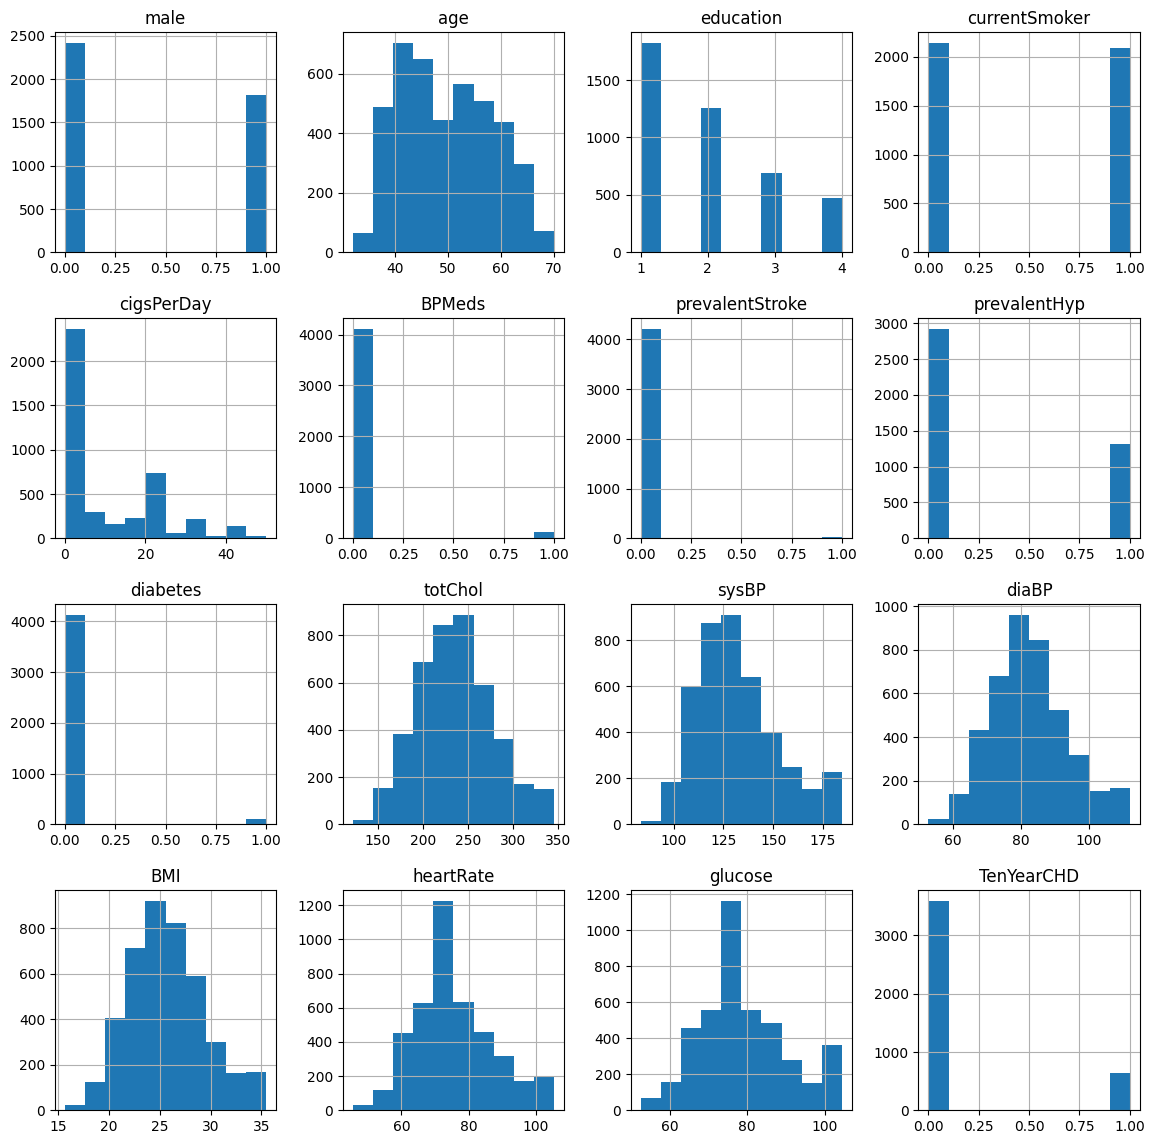

In [15]:
#Univariate analysis
# Visualizing the distribution of each numerical feature using histograms.
df.hist(figsize=(14,14))
plt.show()


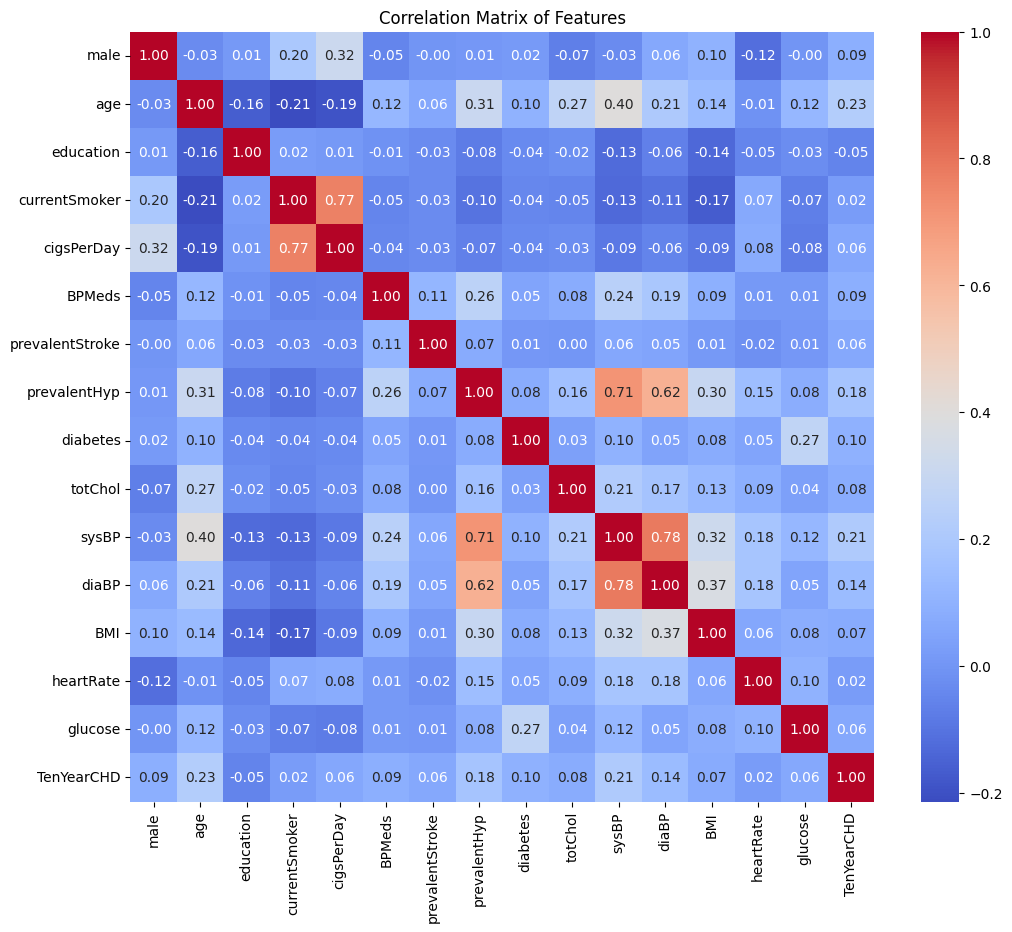

In [16]:
#Bivariate analysis
# correlation matrix
# Analyzing relationships between features using a correlation heatmap.

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


Among all the features, age (0.23), sysBP (0.21), prevalentHyp (0.18), and diaBP (0.14) show the highest positive correlation with the target variable (TenYearCHD), indicating they have the strongest association with the risk of heart disease. Most other features have weak correlations (close to 0), suggesting that no single feature alone strongly predicts heart disease.

##ML Model Building

In [17]:
# Separating independent features (X) and the target variable (y).
x= df.drop('TenYearCHD',axis=1)
y= df['TenYearCHD']

In [18]:
x.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [19]:
y.head()

,TenYearCHD
0,0
1,0
2,0
3,1
4,0


In [20]:
# Splitting the dataset into training and testing sets using stratified sampling.
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [21]:
# Standardizing the feature values using StandardScaler.
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [22]:
# Training the Logistic Regression model
model = LogisticRegression(class_weight="balanced",random_state=42)
model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [23]:
# Predicting heart disease risk for the test dataset.
y_pred = model.predict(x_test)

In [24]:
# Evaluating the model using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.6662735849056604
Precision: 0.24503311258278146
Recall: 0.5736434108527132
F1 Score: 0.3433874709976798
Confusion Matrix:
 [[491 228]
 [ 55  74]]


The model achieved a moderate overall accuracy of 66.63% while identifying 57.36% of actual heart disease cases. Although the precision is relatively low, the improved recall makes the model more suitable for medical screening, where detecting positive cases is a higher priority than maximizing overall accuracy.

In [25]:
# Predicting the 10-year heart disease risk for a new patient.
#Test Case 1 -
new_patient = {
  'male' : 0,
  'age' : 28,
  'education' : 3,
  'currentSmoker' : 0,
  'cigsPerDay' : 0,
  'BPMeds' : 0,
  'prevalentStroke' : 0,
  'prevalentHyp' : 0,
  'diabetes' : 0,
  'totChol' : 170,
  'sysBP' : 110,
  'diaBP' : 70,
  'BMI' : 22,
  'heartRate' : 72,
  'glucose' : 80
}

In [26]:
df_one = pd.DataFrame(new_patient, index=[0])

In [27]:
df_one

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,0,28,3,0,0,0,0,0,0,170,110,70,22,72,80


In [28]:
# Scale the new patient data using the *fitted* scaler
df_one_scaled = scaler.transform(df_one)
pred = model.predict(df_one_scaled)
if pred[0] == 1:
    print("Predicted Class : 1")
    print("Risk of Heart Disease")
else:
    print("Predicted Class : 0")
    print("No Risk of Heart Disease")

Predicted Class : 0
No Risk of Heart Disease


In [29]:
#Test Case 2-
new_pattwo = {
'male' : 1,
'age' : 65,
'education' : 1,
'currentSmoker' : 1,
'cigsPerDay' : 30,
'BPMeds' : 1,
'prevalentStroke' : 0,
'prevalentHyp' : 1,
'diabetes' : 1,
'totChol' : 295,
'sysBP' : 180,
'diaBP' : 110,
'BMI' : 35,
'heartRate' : 95,
'glucose' : 180,
}

In [30]:
df_two = pd.DataFrame(new_pattwo, index=[0])

In [31]:
# Scale the new patient data using the *fitted* scaler
df_two_scaled = scaler.transform(df_two)
pred = model.predict(df_two_scaled)
if pred[0] == 1:
    print("Predicted Class : 1")
    print("Risk of Heart Disease")
else:
    print("Predicted Class : 0")
    print("No Risk of Heart Disease")

Predicted Class : 1
Risk of Heart Disease


In [32]:
#Test Case 3 -
new_Patthree = {
'male' : 0,
'age' : 60,
'education' : 4,
'currentSmoker' : 0,
'cigsPerDay' : 0,
'BPMeds' : 0,
'prevalentStroke' : 0,
'prevalentHyp' : 0,
'diabetes' : 0,
'totChol' : 180,
'sysBP' : 118,
'diaBP' : 76,
'BMI' : 24,
'heartRate' : 70,
'glucose' : 85,
}

In [33]:
df_three = pd.DataFrame(new_Patthree, index=[0])

In [34]:
# Scale the new patient data using the *fitted* scaler
df_three_scaled = scaler.transform(df_three)
pred = model.predict(df_three_scaled)
if pred[0] == 1:
    print("Predicted Class : 1")
    print("Risk of Heart Disease")
else:
    print("Predicted Class : 0")
    print("No Risk of Heart Disease")

Predicted Class : 0
No Risk of Heart Disease


In [35]:
#Test Case 4-
new_Patfour = {
'male' : 1,
'age' : 50,
'education' : 2,
'currentSmoker' : 1,
'cigsPerDay' : 12,
'BPMeds' : 0,
'prevalentStroke' : 0,
'prevalentHyp' : 1,
'diabetes' : 0,
'totChol' : 220,
'sysBP' : 145,
'diaBP' : 90,
'BMI' : 28,
'heartRate' : 80,
'glucose' : 95,
}

In [36]:
df_four = pd.DataFrame(new_Patfour, index=[0])

In [37]:
# Scale the new patient data using the *fitted* scaler
df_four_scaled = scaler.transform(df_four)
pred = model.predict(df_four_scaled)
if pred[0] == 1:
    print("Predicted Class : 1")
    print("Risk of Heart Disease")
else:
    print("Predicted Class : 0")
    print("No Risk of Heart Disease")

Predicted Class : 1
Risk of Heart Disease


In [38]:
#Test Case 5-
new_Patfive = {
    'male': 0,
    'age': 25,
    'education': 4,
    'currentSmoker': 0,
    'cigsPerDay': 0,
    'BPMeds': 0,
    'prevalentStroke': 0,
    'prevalentHyp': 0,
    'diabetes': 0,
    'totChol': 165,
    'sysBP': 108,
    'diaBP': 68,
    'BMI': 21,
    'heartRate': 68,
    'glucose': 78,
}

In [39]:
df_five = pd.DataFrame(new_Patfive, index=[0])

In [40]:
# Scale the new patient data using the *fitted* scaler
df_five_scaled = scaler.transform(df_five)
pred = model.predict(df_five_scaled)
if pred[0] == 1:
    print("Predicted Class : 1")
    print("Risk of Heart Disease")
else:
    print("Predicted Class : 0")
    print("No Risk of Heart Disease")

Predicted Class : 0
No Risk of Heart Disease
